# Experiment gathering data neglict color
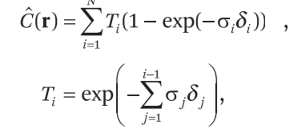


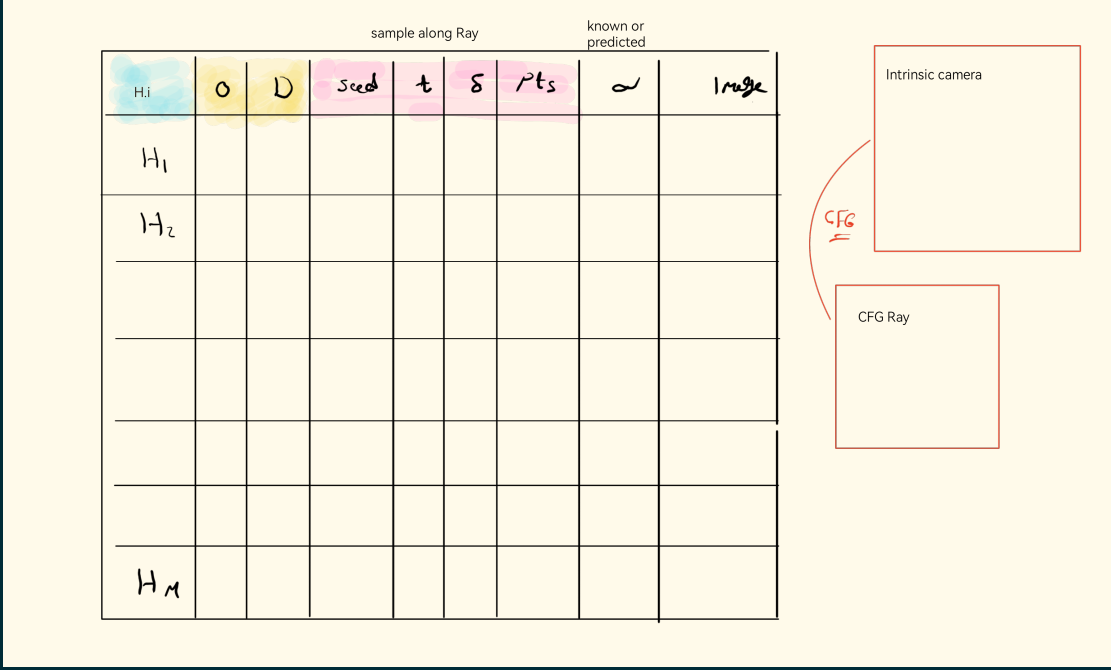


# Demo — Load cached frames & visualize

**What it does**
1) Loads a batch of frames from `<scene>/rays/cache/<cfg_hash>/<split>/...`  
2) Validates invariants (`R == H*W`, unit-norm `D`, monotone `t`).  
3) Visualizes:
   - World + selected camera using `plot_world` (optional)
   - `sigma` as a heatmap / scatter for a chosen frame
   - opacity mask using the binary renderer
4) Shows how to load a single NPZ as numpy or torch.

> **Note:** Assumes you already ran `examples/demo_save_batch.ipynb` to generate cached frames.


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import torch
import matplotlib.pyplot as plt

# nerflab imports (ensure your env has nerflab on PYTHONPATH)
from nerflab import Intrinsics, Camera, CFG, load_world, plot_world
from nerflab.io import (
    load_frame_npz, load_batch, validate_loaded_batch,
    discover_cfg_hash, list_frame_npz, frame_ids_from_paths, camera_from_loaded_H
)
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row
from nerflab.viz.viz_sigma import viz_sigma_heatmap, viz_sigma_scatter, visualize_sigma  # ensure these exist in your version

In [2]:
# -----------------------------
# Utility helpers
# -----------------------------
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility where reasonable."""
    np.random.seed(seed)
    torch.manual_seed(seed)

def to_cpu_numpy(x):
    """Safely move torch tensor to CPU NumPy; return input if not a tensor."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return x

def get_intrinsics_from_cfg() -> Intrinsics:
    """
    Construct Intrinsics from CFG.intrinsics.
    Falls back to constructing from known common keys if needed.
    """
    if hasattr(CFG, "intrinsics"):
        return Intrinsics(**CFG.intrinsics.__dict__)
    possible = ["fx", "fy", "cx", "cy", "width", "height"]
    kw = {k: getattr(CFG, k) for k in possible if hasattr(CFG, k)}
    if len(kw) < 6:
        raise RuntimeError("Could not infer intrinsics from CFG. Please customize get_intrinsics_from_cfg().")
    return Intrinsics(**kw)

# Parameters (edit these)

In [3]:
# ---- Parameters ----
scene_dir = Path("../../data/data_experiment2")   # root scene directory
split      = "train"                             # one of: "train", "val", "test"
seed       = 7
cfg_hash   = None                                # if None, auto-discover from cache folder
num_frames = 5
frame_offset = 0
device     = "cpu"                               # set "cuda" if available
show_world = True                                # set True to plot the world and selected camera
world_json_path = "../data/world.json"           # update if your world.json lives elsewhere
idx_frame_render = 1                              # which frame index (within loaded batch) to render/evaluate
idx_ray_render   = 55350  
save_binary_png = False


# Discover cached frames & list NPZ files

In [4]:
set_seed(seed)

_cfg = cfg_hash or discover_cfg_hash(scene_dir, split)
npz_paths_all = list_frame_npz(scene_dir, _cfg, split)
if len(npz_paths_all) == 0:
    raise RuntimeError("No NPZ files found. Run your capture/save demo first to generate NPZs.")

# Slice a window of frames to work with
npz_paths = npz_paths_all[frame_offset : frame_offset + num_frames]
frame_ids = frame_ids_from_paths(npz_paths)
print(f"[Info] Using cfg_hash={_cfg}, split={split}, frames={frame_ids}")

[Info] Using cfg_hash=9867679e2750, split=train, frames=['000000', '000001', '000002', '000003', '000004']


# Single-frame load (NumPy mode)

In [5]:
npz0 = load_frame_npz(str(npz_paths[0]), as_torch=False)
print(f"[Single frame/NumPy] O shape={npz0['O'].shape}, C shape={npz0['C'].shape}, width={npz0['width']}, height={npz0['height']}")

[Single frame/NumPy] O shape=(307200, 3), C shape=(307200,), width=640, height=480


# Same frame in Torch mode (device-aware)

In [6]:
t0 = load_frame_npz(str(npz_paths[0]), as_torch=True, device=torch.device(device))
assert torch.is_tensor(t0["O"]) and torch.is_tensor(t0["C"]), "Expected torch tensors for O and C"
print("[Single frame/Torch] Loaded tensors on", device)

[Single frame/Torch] Loaded tensors on cpu


# Batch load and validate

In [7]:
batch = load_batch(
    str(scene_dir), _cfg, split, frame_ids,
    seed=seed, as_torch=True, device=torch.device(device)
)
validate_loaded_batch(batch)

print(
    "[Batch] Shapes -> H_wc={}, O={}, C={}, sigma={}, t={}, delta={}, X={}".format(
        tuple(batch.get('H_wc', torch.empty(0)).shape),
        tuple(batch.get('O', torch.empty(0)).shape),
        tuple(batch.get('C', torch.empty(0)).shape),
        tuple(batch.get('sigma', torch.empty(0)).shape),
        tuple(batch.get('t', torch.empty(0)).shape),
        tuple(batch.get('delta', torch.empty(0)).shape),
        tuple(batch.get('X', torch.empty(0)).shape),
    )
)
print(f"[Batch] Keys: {sorted(list(batch.keys()))}")


[Batch] Shapes -> H_wc=(5, 4, 4), O=(5, 307200, 3), C=(5, 307200), sigma=(5, 307200, 40), t=(5, 307200, 40), delta=(5, 307200, 40), X=(5, 307200, 40, 3)
[Batch] Keys: ['C', 'D', 'H_wc', 'O', 'T', 'X', 'cfg_hash', 'delta', 'frame_ids', 'height', 'pix_idx', 'seed', 'sigma', 't', 'w', 'width']


# Plot the world and selected camera

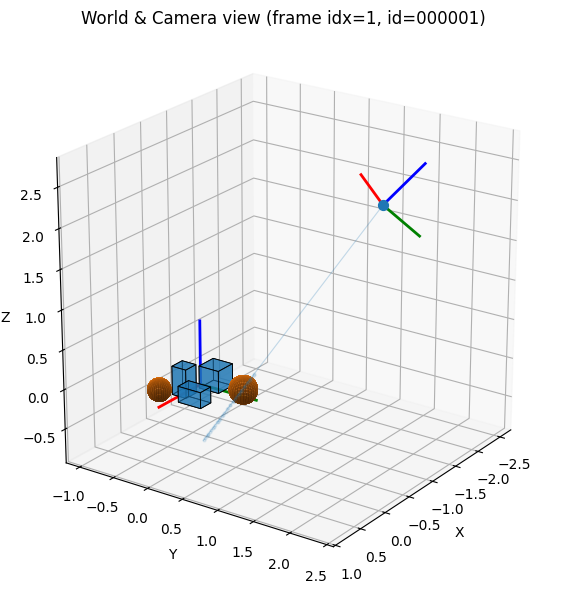

In [8]:
if show_world:
    try:
        world = load_world(world_json_path)
        cam = camera_from_loaded_H(batch["H_wc"])   # Camera(B, ...)
        # idx = None
        idx = max(0, min(idx_frame_render, cam.B - 1))
        title = f"World & Camera view (frame idx={idx}, id={frame_ids[idx]})" if idx is not None else "All cam poses"
        idx_per_pose = torch.tensor([[idx_ray_render]], dtype=torch.long)

        fig, ax =plot_world(
            world,
            cameras=cam,
            cam_indices=[idx] if idx is not None else 'all',
            draw_rays=True,
            draw_samples=True,
            # rays_per_pose=100,
            rays_indices=idx_per_pose,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
            title = title,
        )
        fig.savefig(f"{scene_dir}/world_view.png", dpi=200)
    except Exception as e:
        print("[Warn] World plot skipped due to error:", e)


In [9]:
from nerflab.viz import plot_world_interactive
if show_world:
    # try:
        world = load_world(world_json_path)
        cam = camera_from_loaded_H(batch["H_wc"])  
        idx = max(0, min(idx_frame_render, cam.B - 1))
        title = f"World & Camera view (frame idx={idx}, id={frame_ids[idx]})" if idx is not None else "All cam poses"

        idx_per_pose = torch.tensor([[idx_ray_render]], dtype=torch.long)

        fig, _ = plot_world_interactive(
            world,
            cameras=cam,
            cam_indices=[idx] if idx is not None else "all",
            draw_rays=True,
            draw_samples=True,
            rays_indices=idx_per_pose,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
            title=title,
            save_html=f"{scene_dir}/world_view.html",  # interactive output
            show=True,
        )
        # Optional static preview if you also want a PNG (requires `pip install kaleido`)
        # fig.write_image(f"{scene_dir}/world_view.png", scale=2)
    # except Exception as e:
    #     print("[Warn] World Plotly view skipped due to error:", e)


# Visualize Opacity (Binary render)

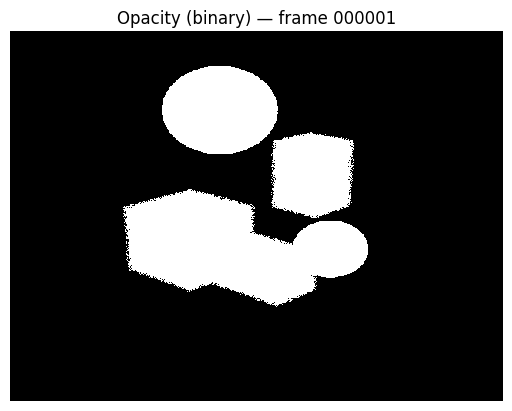

In [10]:
idx = max(0, min(idx_frame_render, batch["C"].shape[0] - 1))
H, W = int(batch["height"]), int(batch["width"])

C_frame = batch["C"][idx]         # (R,)
intr = get_intrinsics_from_cfg()

# Configure binary rendering
save_path = Path(str(scene_dir) + f"/opacity_{frame_ids[idx]}.png") if save_binary_png else None

rnd = Renderer(BinaryRenderCfg(threshold=0.5))
fig, ax, _ = rnd.binary(
    C_frame.reshape(H, W).detach().cpu().numpy(),
    intr=intr,
    title=f"Opacity (binary) — frame {frame_ids[idx]}",
    save_path=str(save_path) if save_path is not None else None,
)
plt.show()
if save_path is not None:
    print(f"[Save] Binary opacity saved to: {save_path}")


# One-stop helper: visualize_sigma

torch.Size([307200, 40])


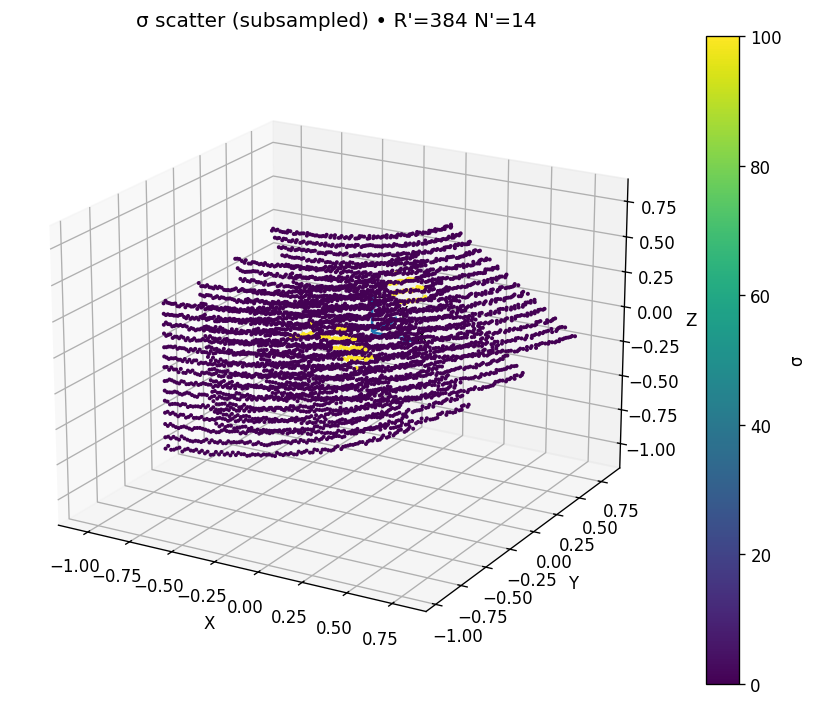

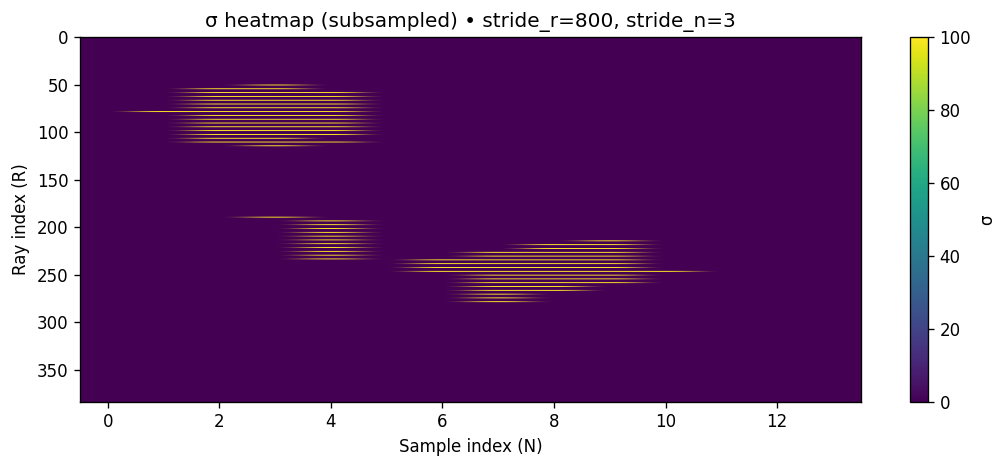

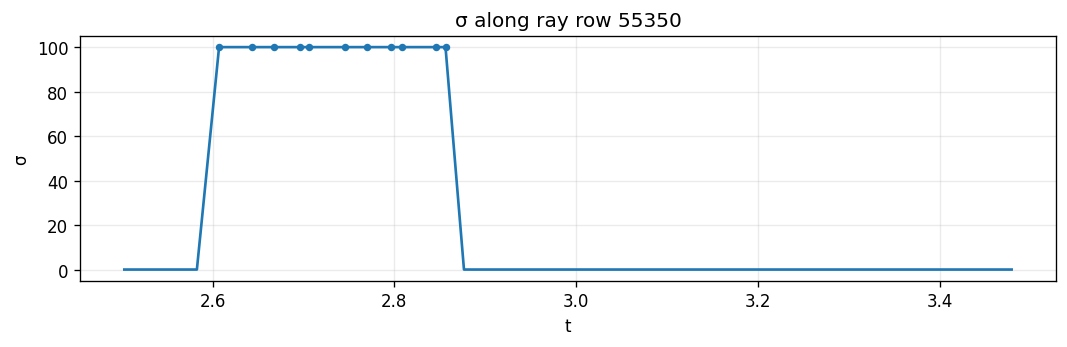

Picked row: 55350 • user‑selected
Row 55350: max σ = 100.000000 at t = 2.607184


In [11]:
t_frame     = batch["t"][idx]       # (R, N)
delta_frame = batch["delta"][idx]   # (R, N)
pts_frame   = batch["X"][idx]       # (R, N, 3)
sigma_frame = batch["sigma"][idx]   # (R, N)
print(sigma_frame.shape)
samples = (t_frame, delta_frame, pts_frame)

try:
    _ = visualize_sigma(samples, sigma_frame, idx_ray_render=idx_ray_render)
    plt.show()
except Exception as e:
    print("[Warn] visualize_sigma skipped:", e)

torch.Size([307200])
tensor(0.)
tensor(3.4219)


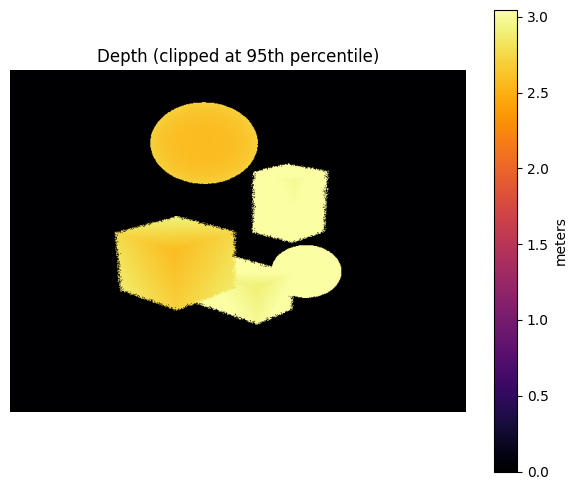

In [12]:
import torch, matplotlib.pyplot as plt

from nerflab.nerf_sigma_learning.ops import render_depth
(t, delta, pts) = samples
depth_map = render_depth(sigma_frame, delta, t)
print(depth_map.shape)
print(depth_map.min())
print(depth_map.max())

# If you know H,W:
D = depth_map.view(H, W)     # reshape

# Optional: clip long tails for nicer contrast (e.g., p95)
hi = torch.quantile(D[D.isfinite()], 0.95).item()
D_vis = torch.clamp(D, 0, hi)

plt.figure(figsize=(6,5))
plt.imshow(D_vis.cpu().numpy(), cmap='inferno')
plt.title("Depth (clipped at 95th percentile)")
plt.axis('off')
plt.colorbar(label='meters')
plt.tight_layout()
plt.show()
